<a href="https://colab.research.google.com/github/CGUILLEN23/pima-diabetes-data-science-project/blob/main/ADS_504_Final_Project_EV_Transition_EDA_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [1]:
from google.colab import files

uploaded = files.upload()

Saving global_ev_adoption_behavior_2026.csv to global_ev_adoption_behavior_2026.csv


In [4]:
df = pd.read_csv("global_ev_adoption_behavior_2026.csv")

In [5]:
df.head()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


In [6]:
df.shape

(50000, 23)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

In [9]:
df.dtypes

,0
age,int64
annual_income,float64
education_level,object
city_type,object
daily_commute_km,float64
weekly_travel_distance_km,float64
current_vehicle_type,object
vehicle_age_years,float64
fuel_expense_per_month,float64
charging_station_accessibility,float64


In [10]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage
education_level,500,1.0
charging_station_accessibility,500,1.0
ev_knowledge_score,500,1.0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["ev_adoption_likelihood"].value_counts()

,count
ev_adoption_likelihood,
High,29670
Medium,12078
Low,8252


In [13]:
df["ev_adoption_likelihood"].value_counts(normalize=True) * 100

,proportion
ev_adoption_likelihood,
High,59.340
Medium,24.156
Low,16.504


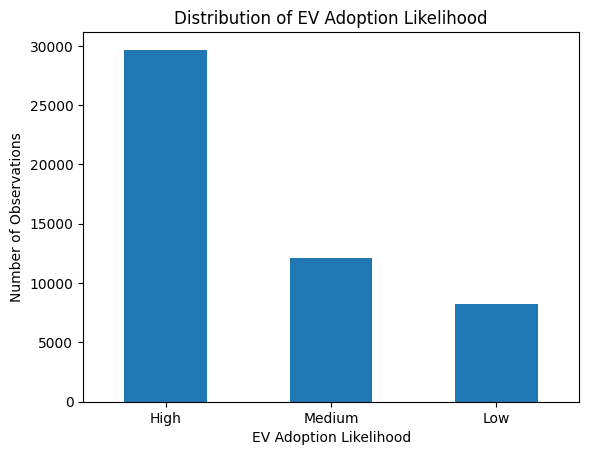

In [14]:
import matplotlib.pyplot as plt

df["ev_adoption_likelihood"].value_counts().plot(kind="bar")

plt.title("Distribution of EV Adoption Likelihood")
plt.xlabel("EV Adoption Likelihood")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.show()

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,44.996080,14.110844,21.00,33.00,45.00,57.00,69.00
annual_income,50000.0,44311.869380,26109.170784,5104.00,25617.75,37891.00,56051.25,250000.00
daily_commute_km,50000.0,35.169358,14.736042,5.00,25.00,35.10,45.20,97.90
weekly_travel_distance_km,50000.0,228.727200,101.147254,25.00,157.70,224.10,294.50,732.30
vehicle_age_years,50000.0,6.012842,2.947132,0.00,3.90,6.00,8.00,20.00
fuel_expense_per_month,50000.0,295.169608,130.178552,-99.70,205.20,294.80,383.00,862.00
charging_station_accessibility,49500.0,5.892947,2.152186,1.00,4.40,5.90,7.40,10.00
nearest_charging_station_km,50000.0,7.132370,4.801992,0.50,3.00,6.90,10.70,28.50
home_charging_available,50000.0,0.649760,0.477050,0.00,0.00,1.00,1.00,1.00
electricity_cost_per_kwh,50000.0,0.215359,0.077914,0.08,0.15,0.22,0.28,0.35


In [16]:
(df["fuel_expense_per_month"] < 0).sum()

np.int64(271)

In [17]:
df[df["fuel_expense_per_month"] < 0][
    ["fuel_expense_per_month", "daily_commute_km", "current_vehicle_type"]
].head(10)

,fuel_expense_per_month,daily_commute_km,current_vehicle_type
18,-0.7,5.0,Sedan
27,-0.8,7.9,Truck
29,-19.2,5.0,Sedan
137,-11.9,6.0,Sedan
492,-4.5,5.7,Hatchback
688,-22.5,9.7,Sedan
746,-9.2,5.0,SUV
821,-17.5,5.1,Hatchback
874,-20.8,5.0,Sedan
1089,-8.4,5.0,Sedan
